# Results for Terschelling
- Difference statistics compared to JARKUS: Does it improve compared to the initial state?
- Volume changes
- Elevation changes for a few selected points
- Animation gif

## Paths & Co

In [65]:
new_initial_state = False
new_kalman_run = False
animation = False

In [2]:
# paths jupyter utwente
path_tc = '/home/jovyan/data/98_paper2_kf_dtm/01_tides/output/'

path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/12_13_Ters_DEM/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/12_13_Ters_DEM/output/'
path_altimetry_output = '/home/jovyan/data/98_paper2_kf_dtm/11_Ters_altimetry/output/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2023_n53.5439_s53.2693_w5.0194_e5.6607.nc'
fn_ddtm = 'DeltaDTM_v1_0_N53E005.tif'

In [3]:
# other settings
# epsg = 28992 # Amersfoort
epsg = 4326 # WGS84

year_start = 1993
year_end = 2020 # included

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [4]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import time
import itertools

from scipy import stats

from shapely import LineString
from shapely.ops import split

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# from cmcrameri import cm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools, CD_matrix_tools, CD_visualisation

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [5]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=MEDIUM_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Parameters

In [6]:
# Observational noise
beach_slope = 0.015 # tan beta
rmse_h_cassie = 20 # [m]
std_alt = 0.1 # [m]
rms_eot20 = 0.1  # [m]
sigma_l = np.sqrt((beach_slope * rmse_h_cassie)**2 + std_alt**2 + rms_eot20**2)

print(f'Observational noise: {round(sigma_l,2)} m')

# Model noise
factor = 10
sigma_q = factor * sigma_l
print(f'Model noise: {round(sigma_q,2)} m')

# Standard deviation of the initial state
std_init = 1
print(f'Standard deviation of the initial state: {round(std_init,2)} m')

Observational noise: 0.33 m
Model noise: 3.32 m
Standard deviation of the initial state: 1 m


In [7]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Data

### Observations

In [8]:
# Altimetry
fn = 'tp_plus_ales_epsg28992.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [9]:
# Tidal correction
fn = 'tides_ters.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

In [10]:
# Cassie shorelines
folders = ['12_cassie_landsat_1984-04-30_1992-09-04_ext1000_spac5000_base2_multi-thresh/',\
          '13_cassie_landsat_1992-09-20_2003-08-02_ext1000_spac5000_base2_multi-thresh/',\
          '18_cassie_landsat_2003-09-19_2015-03-12_ext1300_spac5000_base1_multi-thresh/',\
          '17_cassie_landsat_2015-04-13_2023-02-22_ext1300_spac5000_base1_multi-thresh/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

118 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 790 points (min: 156, max: 1475).


### Initial state

In [11]:
resolution = 100 # [m], resolution of the target grid in x- and y-direction
fn_init = f'init_{epsg}_resolution_{resolution}m.tif'
if (not os.path.isfile(path_output + fn_init)) | new_initial_state:
    buffer_size = 500 # [m], buffer radius of target area around the set of shorelines    
    smooth_factor = 100 # Smoothing of shorelines used to compute the median shoreline

    if epsg == 4326:
        buffer_size = CD_geometry.dist_meter_to_dist_deg(buffer_size) # [deg]
        resolution = CD_geometry.dist_meter_to_dist_deg(resolution) # [deg]

    # Target area
    # alpha (how much slack around the concave hull)
    if epsg == 4326:
        alpha = 100
    elif epsg == 28992:
        alpha = 3e-4    

    # Polgon around the shorelines
    poly_shorelines = CD_geometry.get_area_covered_by_shorelines(c_shorelines, alpha=alpha, buffer_size=0)

    # Polygon of target area (shoreline polygon with buffer)
    # poly_target = poly_shorelines.buffer(buffer_size)

    # Buffer around median shoreline 
    med_sl = CD_geometry.median_shoreline_from_transect_intersections(c_shorelines, spacing=100, transect_length=5000, smooth_factor=smooth_factor)
    poly_target = med_sl.buffer(buffer_size)

    # Buffer around zero-contour
    # poly_target = zcontour.buffer(buffer_size)

    pickle.dump(med_sl, open(path_output + f'med_sl{epsg}.pkl', 'wb'))
    pickle.dump(poly_target, open(path_output + f'poly_target{epsg}.pkl', 'wb'))
    pickle.dump(poly_shorelines, open(path_output + f'poly_sl_{epsg}.pkl', 'wb'))


    CD_kalman.initial_state(poly_target, med_sl, epsg, resolution, c_shorelines, alt,
                            path_input+'2_global_DEMs/', path_output, fn_init, fn_gebco, fn_ddtm)
else:
    med_sl = pickle.load(open(path_output + f'med_sl{epsg}.pkl', 'rb')) 
    poly_target = pickle.load(open(path_output + f'poly_target{epsg}.pkl', 'rb')) 
    poly_shorelines = pickle.load(open(path_output + f'poly_sl_{epsg}.pkl', 'rb'))

Always load `init`, even if it was computed in this go (otherwise there is one case where init is a dataframe, and one case where it is an xarray DataSet):

In [12]:
init = xr.open_dataset(path_output+fn_init).squeeze()

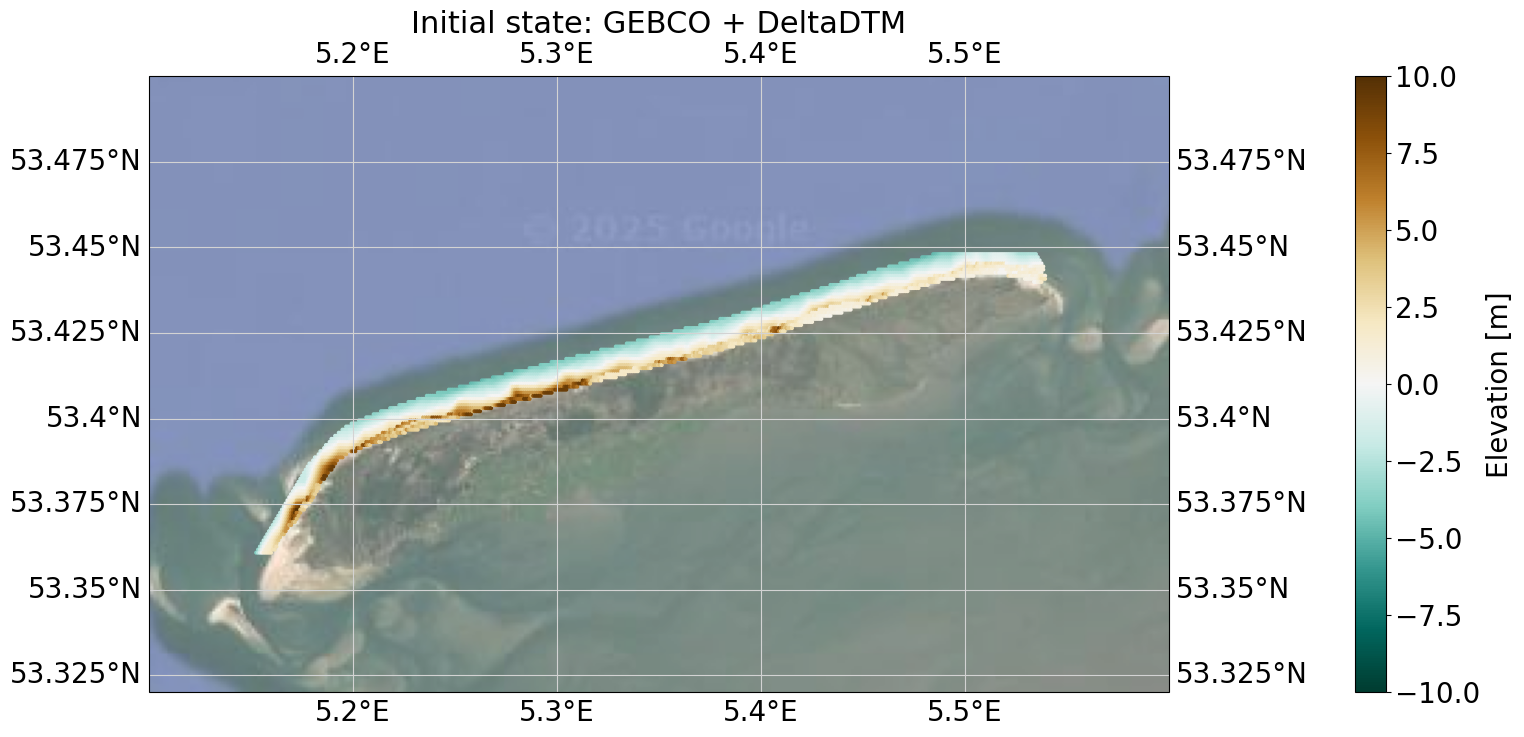

In [13]:
# Plot intial state
init_df = init.to_dataframe()
x = init_df.index.get_level_values('x')
y = init_df.index.get_level_values('y')

projection = ccrs.PlateCarree()
request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(20,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)
plot = ax.scatter(x, y, c=init_df.band_data, transform=projection, marker='.', s=15,
                  cmap='BrBG_r', vmin=-10, vmax=10)

fig.colorbar(plot, shrink=1, pad=0.12, label='Elevation [m]')
ax.set_title('Initial state: GEBCO + DeltaDTM', fontsize=22);

plt.savefig(f'{path_output}initial_state.png', dpi=300, bbox_inches='tight')

### Jarkus data

In [14]:
jarkus_gdf = CD_jarkus_tools.get_jarkus_data(path_input_general, year_start, year_end, poly_target, init)

### Shoreline outlier rejection
(apart from observations, because requires initial state, and initial state computation requires shorelines, but not necessarily outlier-corrected)

In [15]:
# shoreline outlier rejection
init_df = init.to_dataframe().reset_index().dropna()
zcontour = CD_geometry.get_DEM_contour(init_df['x'], init_df['y'], init_df['band_data'], h=0, tarea=poly_target)

t_factor = .9 # threshold = t_factor * mean, (mean of distances to reference shoreline), points inside that range are kept
c_shorelines_corr = CD_geometry.shoreline_outlier_rejection(c_shorelines, zcontour, epsg, t_factor)

25.0% of shoreline points were discarded.


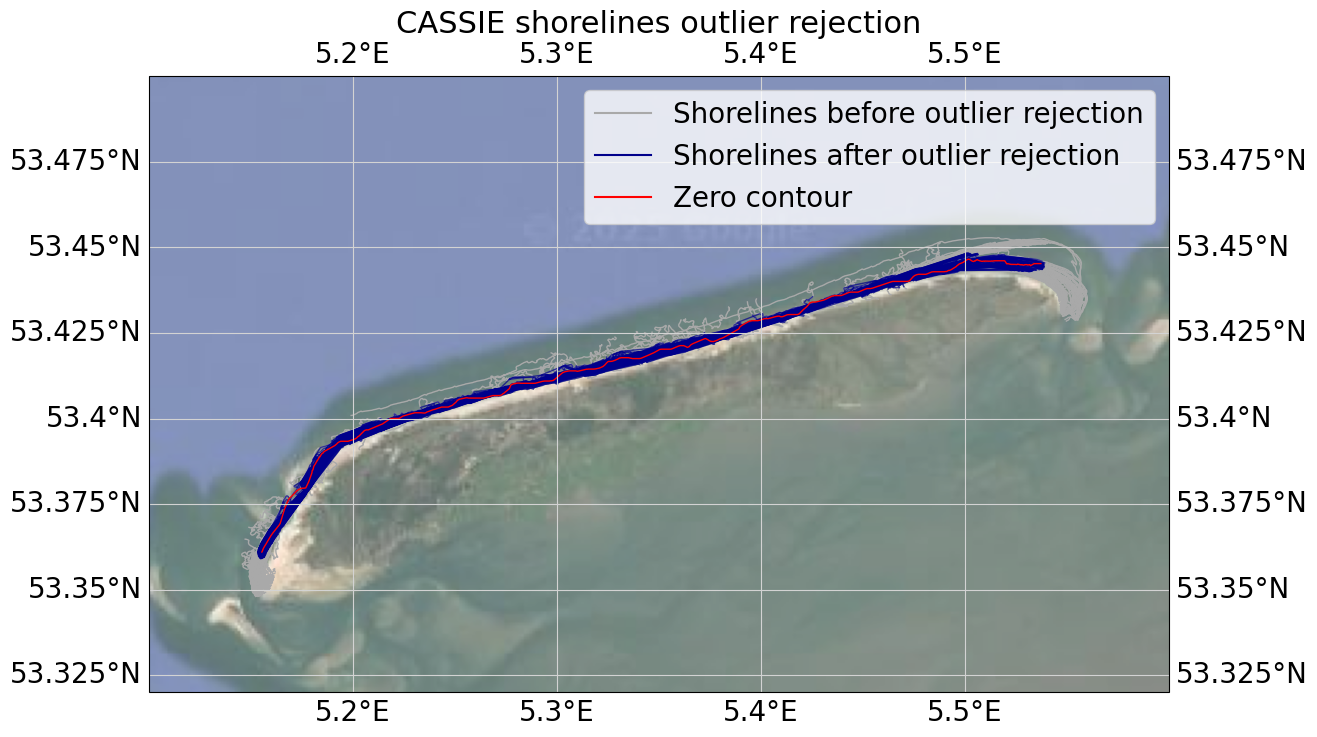

In [16]:
projection = ccrs.PlateCarree()
request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(20,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)
ax.set_title('CASSIE shorelines outlier rejection', fontsize=22);

for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='darkgrey', zorder=1, alpha=1)
for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=.7)
    
ax.add_geometries(zcontour, crs=projection, facecolor='none', edgecolor='red', zorder=1, alpha=1)

proxy_before = Line2D([0], [0], color='darkgrey', label='Shorelines before outlier rejection')
proxy_after = Line2D([0], [0], color='darkblue', label='Shorelines after outlier rejection')
proxy_zcontour = Line2D([0], [0], color='red', label='Zero contour')
ax.legend(handles=[proxy_before, proxy_after, proxy_zcontour])

# plt.savefig(f'{path_output}shoreline_outlier_rejection.png', dpi=300, bbox_inches='tight')

In [17]:
poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=0)

### Coastline section polygons

In [18]:
jarkus = xr.open_dataset(path_input_general + 'transect_red_with_derivatives.nc') #(only required to generate coastline section areas for volume changes)
poly_all, poly_west, poly_center, poly_east = CD_jarkus_tools.get_Ters_section_polygons(poly_target, jarkus, buffer_vol=-250)
# poly_all, poly_west, poly_center, poly_east = CD_jarkus_tools.get_Ters_section_polygons(poly_sl_corr, jarkus, buffer_vol=0)

Reduced target polygon by 50.4 %


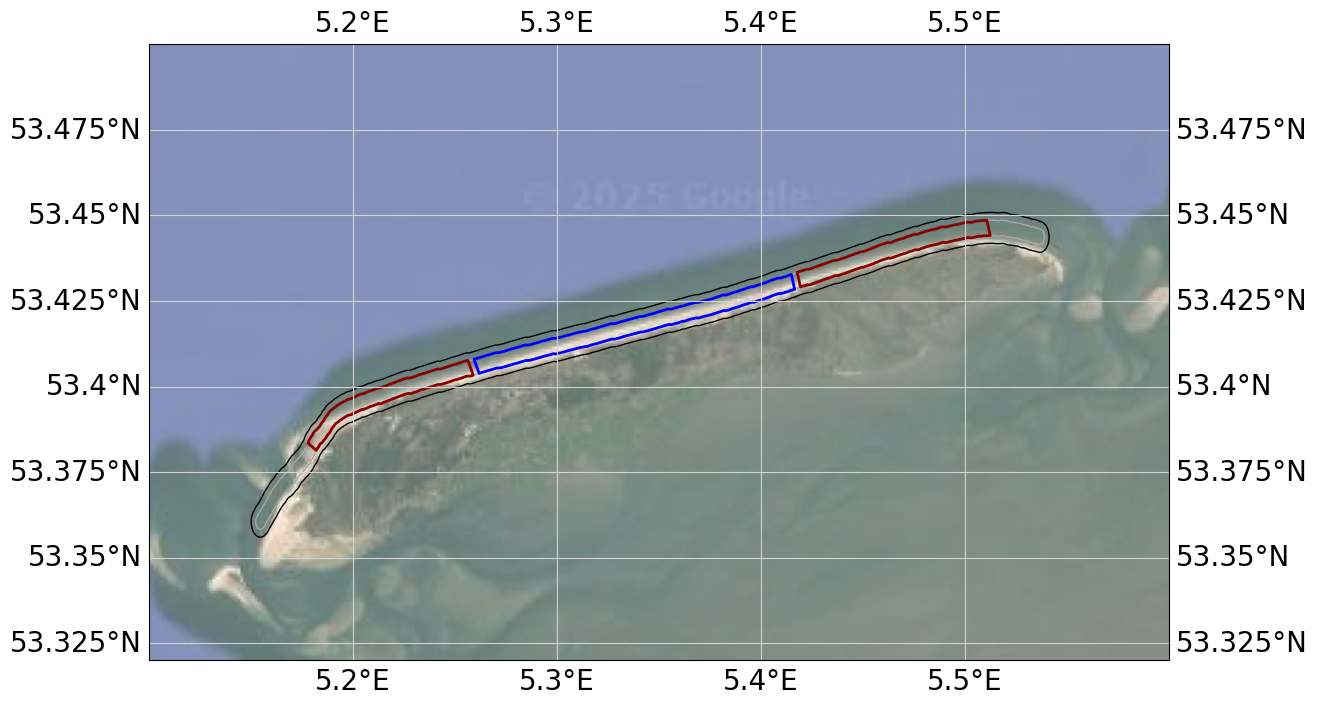

In [19]:
# Plot intial state
projection = ccrs.PlateCarree()
request = cimgt.GoogleTiles(style="satellite")
fig, ax = plt.subplots(figsize=(20,8), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

ax.add_geometries(poly_target, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='black')
ax.add_geometries(poly_all, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkgrey')
ax.add_geometries(poly_west, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkred', linewidth=2)
ax.add_geometries(poly_center, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='blue', linewidth=2)
ax.add_geometries(poly_east, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkred', linewidth=2)

## Generate RTS-DTM

In [20]:
# %%prun -s cumulative
fn = 'x_state_s.pkl'
if (not os.path.isfile(path_output + fn)) | new_kalman_run:
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m] # segment length used for equalise line string
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]
    
    x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(year_start, year_end, init, std_init, rs_shoreline, seg_length, alt, tidal_corr,
                                                                                          epsg, T_is_identity, max_distance, w_id, max_noupdate, std_pseudobs,
                                                                                          sigma_l, sigma_q, eps_factor)
            
    x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, year_end, T, eps_factor)
        
    kf_interp, rts_interp = CD_kalman.interpolate_results(jarkus_gdf, x_state, x_state_s, updated_points)

    # Save kf output
    pickle.dump(x_state, open(f'{path_output}x_state.pkl', 'wb'))
    pickle.dump(sigma_xx_up, open(f'{path_output}sigma_xx_up.pkl', 'wb'))
    pickle.dump(sigma_xx_pred, open(f'{path_output}sigma_xx_pred.pkl', 'wb'))
    pickle.dump(updated_points, open(f'{path_output}updated_points.pkl', 'wb'))
    
    # Save RTS output
    pickle.dump(x_state_s, open(f'{path_output}x_state_s.pkl', 'wb'))
    pickle.dump(sigma_xx_s, open(f'{path_output}sigma_xx_s.pkl', 'wb'))

    # Save interpolated outputs
    pickle.dump(kf_interp, open(f'{path_output}kf_interp.pkl', 'wb'))
    pickle.dump(rts_interp, open(f'{path_output}rts_interp.pkl', 'wb'))
else:
    # Load KF output
    x_state = pickle.load(open(f'{path_output}x_state.pkl', 'rb'))
    sigma_xx_up = pickle.load(open(f'{path_output}sigma_xx_up.pkl', 'rb'))
    sigma_xx_pred = pickle.load(open(f'{path_output}sigma_xx_pred.pkl', 'rb'))
    updated_points = pickle.load(open(f'{path_output}updated_points.pkl', 'rb'))

    # Load RTS output
    x_state_s = pickle.load(open(f'{path_output}x_state_s.pkl', 'rb'))
    sigma_xx_s = pickle.load(open(f'{path_output}sigma_xx_s.pkl', 'rb'))

    # Load interpolated outputs
    kf_interp = pickle.load(open(f'{path_output}kf_interp.pkl', 'rb'))
    rts_interp = pickle.load(open(f'{path_output}rts_interp.pkl', 'rb'))
    
    print(f"Loaded files from {path_output}.")
    

Loaded files from /home/jovyan/data/98_paper2_kf_dtm/12_13_Ters_DEM/output/.


## Statistics of elevation differences

In [21]:
jarkus_gdf = jarkus_gdf.drop(columns=['2001','2002', '2003', '2012'], errors='ignore')
kf_interp = kf_interp.drop(columns=['2001', '2003'], errors='ignore')
rts_interp = rts_interp.drop(columns=['2001', '2003'], errors='ignore')

In [22]:
init_interp = gpd.GeoDataFrame(
        {'geometry':gpd.points_from_xy(jarkus_gdf.geometry.x, jarkus_gdf.geometry.y)}).set_crs('4326')
init_interp['init'] = CD_jarkus_tools.interpolate_irregular_grid_onto_JARKUS(x_state, 'init', jarkus_gdf.geometry.x, jarkus_gdf.geometry.y)

In [23]:
# Reduce to area inside the shoreline polygon
init_inside_sl = init_interp[init_interp.intersects(poly_sl_corr)]
jarkus_inside_sl = jarkus_gdf[jarkus_gdf.intersects(poly_sl_corr)]
kf_inside_sl = kf_interp[kf_interp.intersects(poly_sl_corr)]
rts_inside_sl = rts_interp[rts_interp.intersects(poly_sl_corr)]

### Initial state - Jarkus

In [24]:
jarkus_temp_mean = jarkus_gdf.drop(columns='geometry').T.mean()

diff_init = init_interp['init'] - jarkus_temp_mean
print(f'Difference initial state - jarkus has {len(diff_init.dropna())} non-NaN values.')

Difference initial state - jarkus has 2917 non-NaN values.


In [25]:
CD_statistics.print_stats(diff_init)

Mean error: -0.14 m
---De-bias with mean---
Mean error: -0.0 m
Mean absolute error: 1.58 m
Root mean square error: 2.63 m
Mean absolute deviation from mean: 1.58 m
Median absolute deviation from median: 0.92 m


In [26]:
year_list = [int(_) for _ in jarkus_inside_sl.drop(columns='geometry').columns]
stats_gdf_init, all_diffs_init = CD_statistics.all_stats_per_year(init_interp['init'], jarkus_gdf, year_list, reduce_mean=True, static=True)

# Consider only points inside shoreline polygon
stats_gdf_init_in_sl, all_diffs_init_in_sl = CD_statistics.all_stats_per_year(init_inside_sl['init'], jarkus_inside_sl, year_list, reduce_mean=True, static=True)

### RTS/KF-DTM - Jarkus

In [27]:
year_list = [int(_) for _ in rts_interp.drop(columns='geometry').columns]
stats_gdf_rts, all_diffs_rts = CD_statistics.all_stats_per_year(rts_interp, jarkus_gdf, year_list, reduce_mean=True, static=False)
stats_gdf_kf, all_diffs_kf = CD_statistics.all_stats_per_year(kf_interp, jarkus_gdf, year_list, reduce_mean=True, static=False)

# Consider only points inside shoreline polygon
stats_gdf_rts_in_sl, all_diffs_rts_in_sl = CD_statistics.all_stats_per_year(rts_inside_sl, jarkus_inside_sl, year_list, reduce_mean=True, static=False)
stats_gdf_kf_in_sl, all_diffs_kf_in_sl = CD_statistics.all_stats_per_year(kf_inside_sl, jarkus_inside_sl, year_list, reduce_mean=True, static=False)

In [28]:
c_init = 'grey'
c_kf = 'brown'
c_rts = 'orange'

In [58]:
def plot_stats(ax, which_stat, title, legend=False, inside_sl=False):
    if inside_sl==False:
        ax.plot(stats_gdf_init.index.astype('int'), stats_gdf_init[which_stat], '.-', c=c_init, label='Initial state - Validation')
        ax.plot(stats_gdf_kf.index.astype('int'), stats_gdf_kf[which_stat], '.-', c=c_kf, label='KF-DTM - Validation')
        ax.plot(stats_gdf_rts.index.astype('int'), stats_gdf_rts[which_stat], '.-', c=c_rts, label='RTS-DTM - Validation')
    
    elif inside_sl==True:
        ax.plot(stats_gdf_init_in_sl.index.astype('int'), stats_gdf_init_in_sl[which_stat], '.-', c=c_init, label='Initial state - Validation')
        ax.plot(stats_gdf_kf_in_sl.index.astype('int'), stats_gdf_kf_in_sl[which_stat], '.-', c=c_kf, label='KF-DTM - Validation')
        ax.plot(stats_gdf_rts_in_sl.index.astype('int'), stats_gdf_rts_in_sl[which_stat], '.-', c=c_rts, label='RTS-DTM - Validation')
    
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=25)
    ax.set_xlabel('Year')
    ax.set_ylabel('[m]')
    ax.set_title(title, fontsize=23, y=1)
    # ax.ticklabel_format(useOffset=False, style='plain')

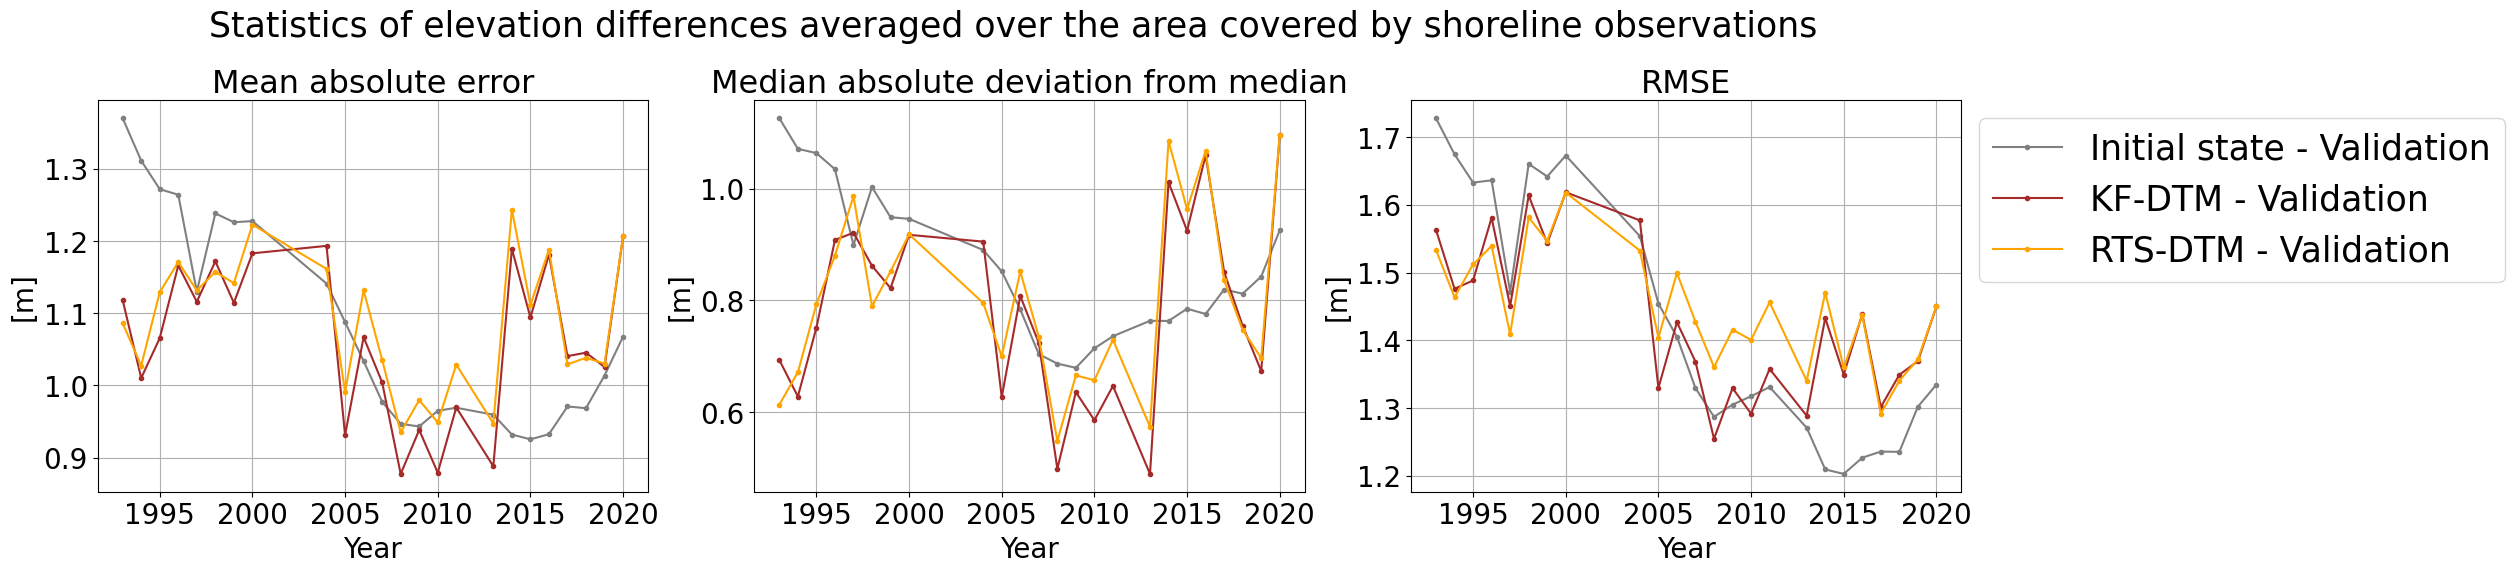

In [59]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
fig.suptitle('Statistics of elevation differences averaged over the area covered by shoreline observations', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error', inside_sl=True)
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median', inside_sl=True)
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True, inside_sl=True)

plt.savefig(f'{path_output}Ters_vali_stats_elev-diffs_inside_shoreline_poly.png', dpi=300, bbox_inches='tight')

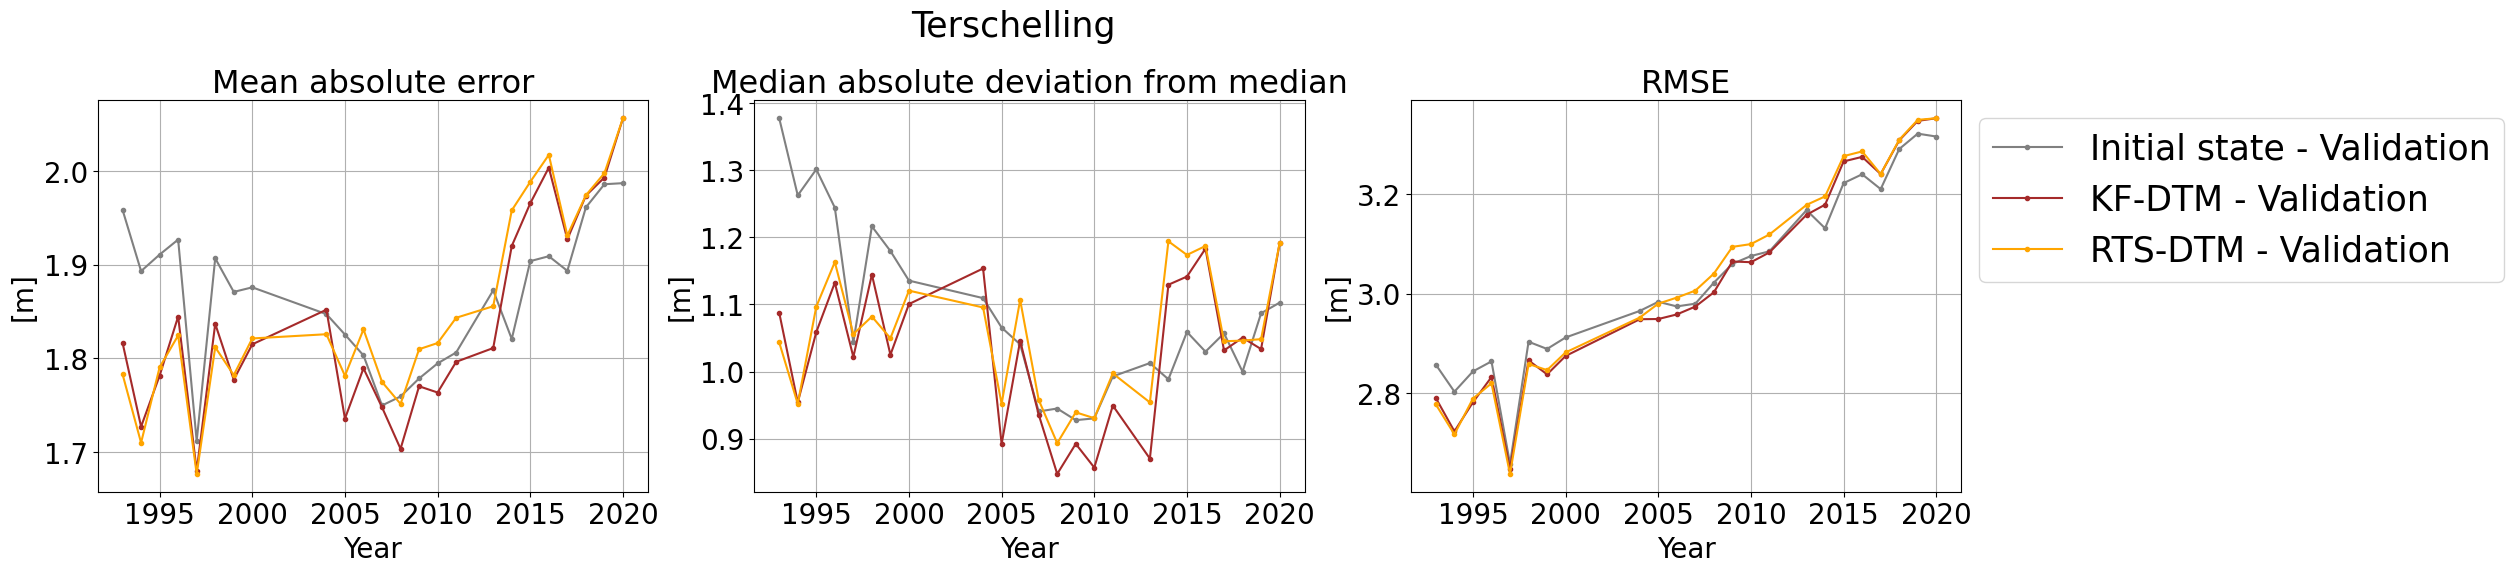

In [64]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
# fig.suptitle('Statistics of elevation differences averaged over the entire target area', y=1.1, fontsize=25)
fig.suptitle('Terschelling', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error')
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median')
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True)

plt.savefig(f'{path_output}Ters_vali_stats_elev-diffs_entire_target_area.png', dpi=300, bbox_inches='tight')

#### Histograms

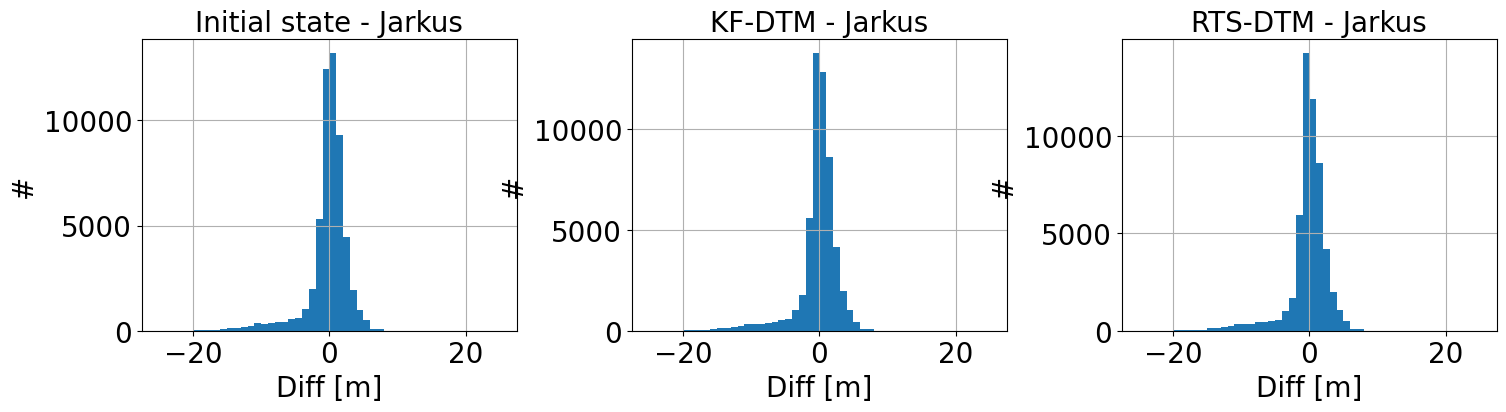

In [32]:
fig, axs = plt.subplots(1,3, figsize=(15,4))
fig.tight_layout()
CD_visualisation.plot_histogram(axs[0], all_diffs_init, 'Initial state - Jarkus')
CD_visualisation.plot_histogram(axs[1], all_diffs_kf, 'KF-DTM - Jarkus')
CD_visualisation.plot_histogram(axs[2], all_diffs_rts, 'RTS-DTM - Jarkus')

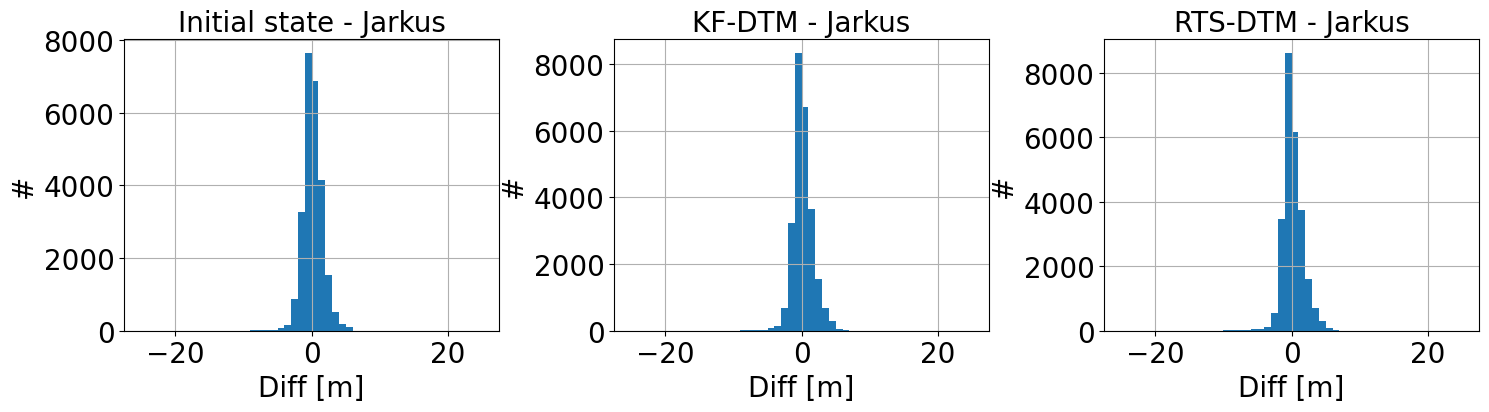

In [33]:
fig, axs = plt.subplots(1,3, figsize=(15,4))
fig.tight_layout()
CD_visualisation.plot_histogram(axs[0], all_diffs_init_in_sl, 'Initial state - Jarkus')
CD_visualisation.plot_histogram(axs[1], all_diffs_kf_in_sl, 'KF-DTM - Jarkus')
CD_visualisation.plot_histogram(axs[2], all_diffs_rts_in_sl, 'RTS-DTM - Jarkus')

### Maps

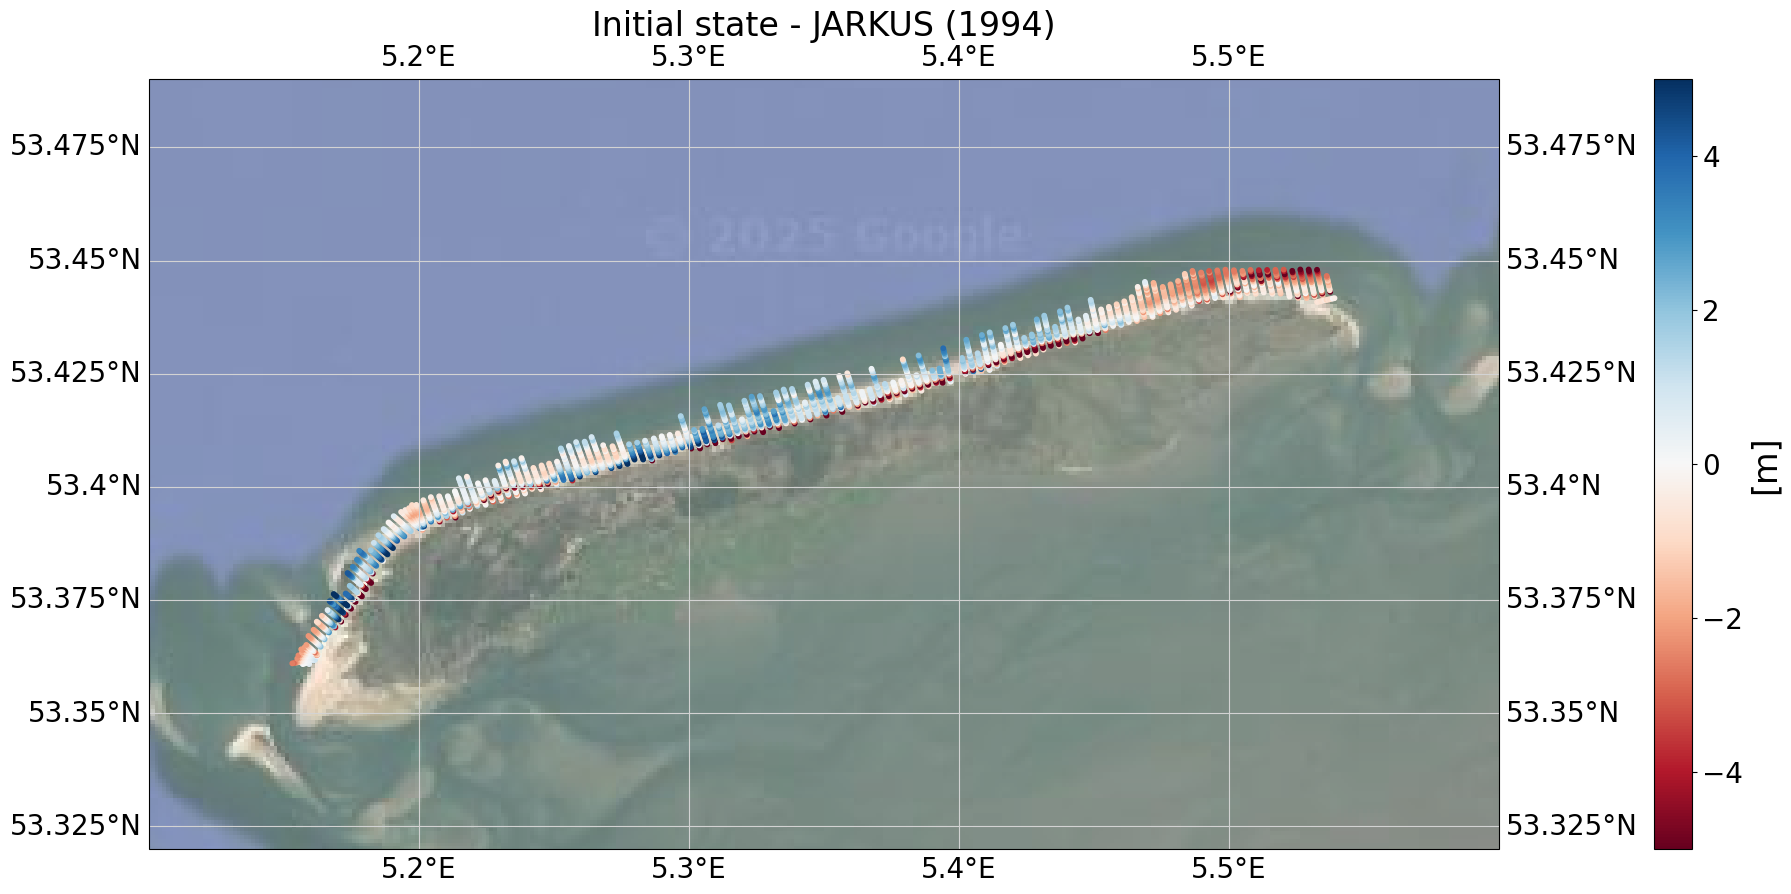

In [34]:
diff = init_interp['init'] - jarkus_gdf['1994']

fig, ax = plt.subplots(figsize=(25,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

x = init_interp.geometry.x
y = init_interp.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff, transform=ccrs.PlateCarree(),
                  cmap='RdBu', vmin=-5, vmax=5)

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title('Initial state - JARKUS (1994)', fontsize=24);

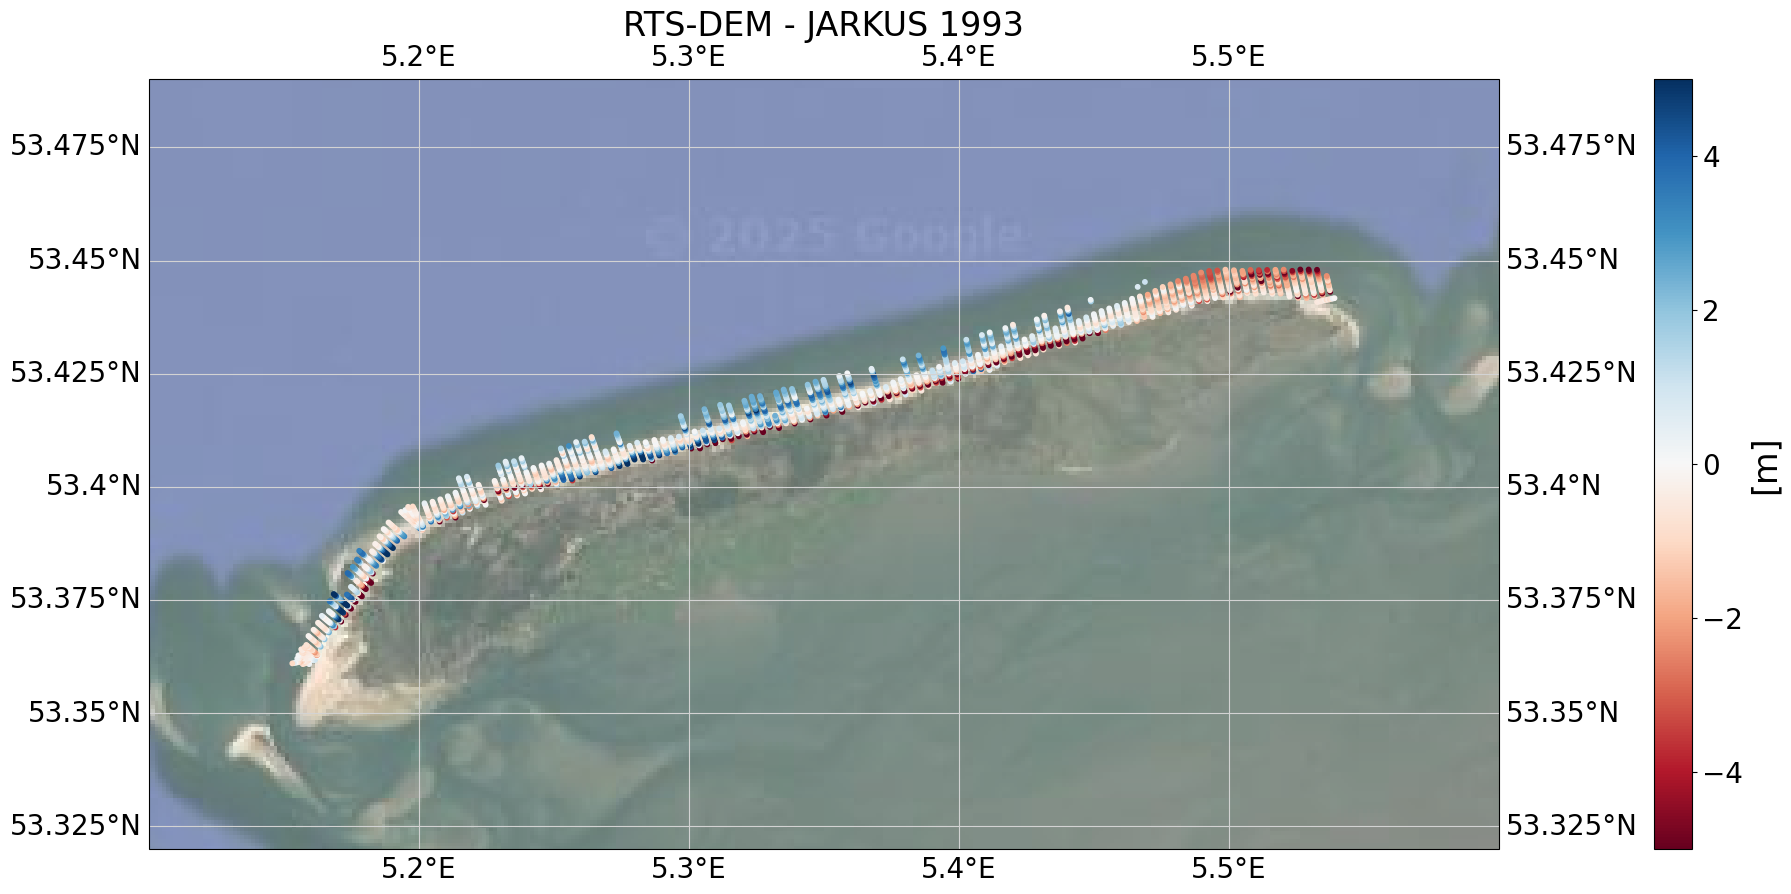

In [35]:
diff = rts_interp['1993'] - jarkus_gdf['1993']

fig, ax = plt.subplots(figsize=(25,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

x = jarkus_gdf.geometry.x
y = jarkus_gdf.geometry.y
plot = ax.scatter(x, y, marker='o', s=10, c=diff, transform=ccrs.PlateCarree(),
                  cmap='RdBu', vmin=-5, vmax=5)

plt.colorbar(plot, shrink=1, pad=.08).set_label(label='[m]',size=24)
ax.set_title('RTS-DEM - JARKUS 1993', fontsize=24);

## Time series of volume changes

In [60]:
def plot_volume_changes(ax, vol_jarkus, vol_kf, vol_rts, title_area, legend=False):
    ax.plot(vol_jarkus.index, vol_jarkus, '.-', c=c_init, label='Validation')
    ax.plot(vol_kf.index, vol_kf, '.-', c=c_kf, label='KF-DTM')
    ax.plot(vol_rts.index, vol_rts, '.-', c=c_rts, label='RTS-DTM')
    ax.set_ylabel(r'[$m^3$]')
    ax.set_xlabel('Year')
    ax.set_title(f'{title_area}', fontsize=22)
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=22)    

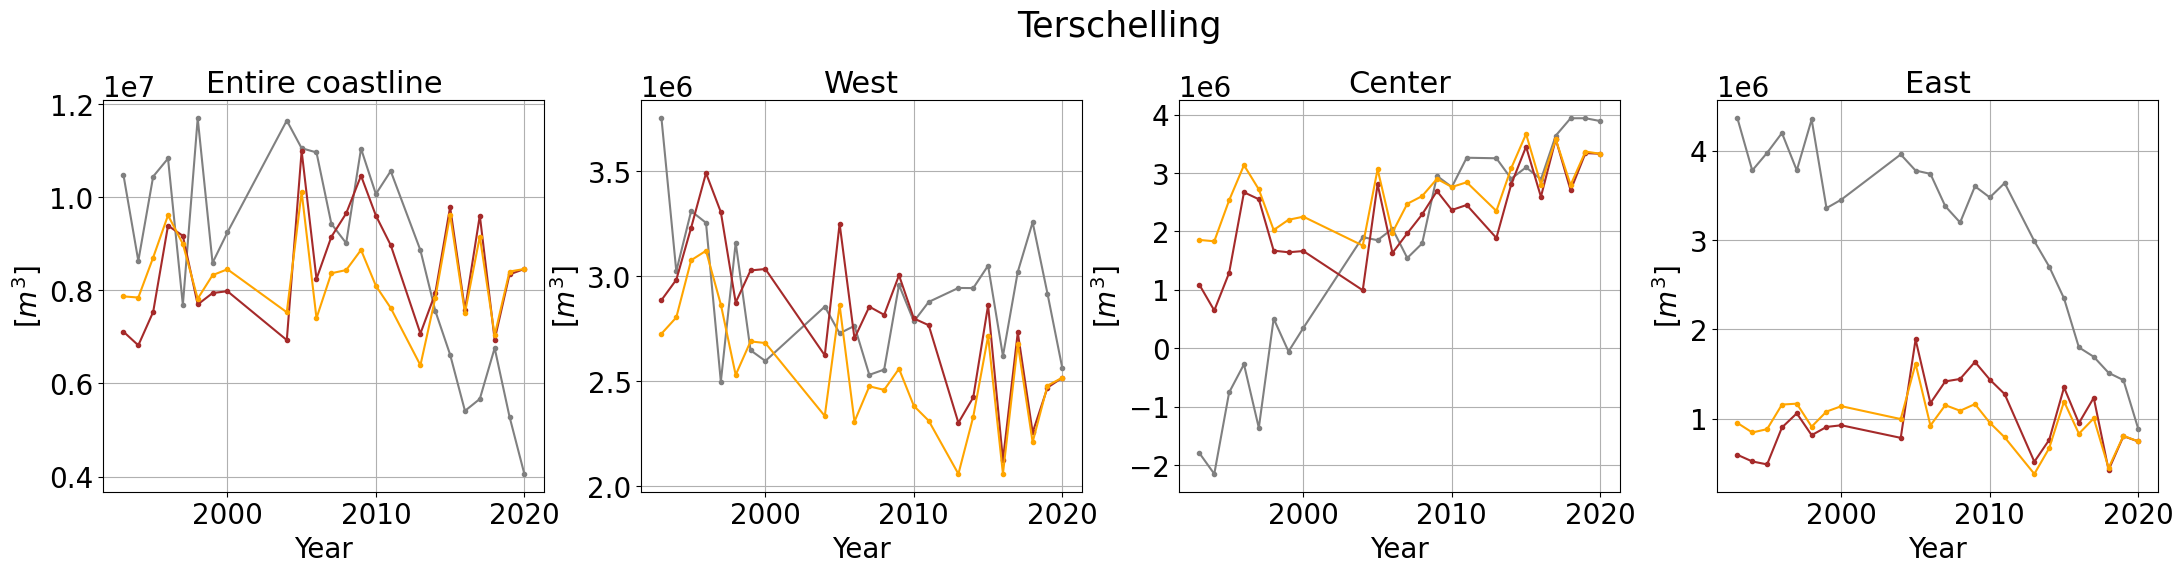

In [62]:
volumes = pd.DataFrame(index=[int(_) for _ in jarkus_gdf.drop(columns='geometry').columns])

volumes['jarkus_all'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_all, col_name='', epsg_out=28992)
volumes['kf_all'] = CD_geometry.compute_volume_changes(kf_interp, poly_all, col_name='', epsg_out=28992)
volumes['rts_all'] = CD_geometry.compute_volume_changes(rts_interp, poly_all, col_name='', epsg_out=28992)

volumes['jarkus_west'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_west, col_name='', epsg_out=28992)
volumes['kf_west'] = CD_geometry.compute_volume_changes(kf_interp, poly_west, col_name='', epsg_out=28992)
volumes['rts_west'] = CD_geometry.compute_volume_changes(rts_interp, poly_west, col_name='', epsg_out=28992)

volumes['jarkus_center'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_center, col_name='', epsg_out=28992)
volumes['kf_center'] = CD_geometry.compute_volume_changes(kf_interp, poly_center, col_name='', epsg_out=28992)
volumes['rts_center'] = CD_geometry.compute_volume_changes(rts_interp, poly_center, col_name='', epsg_out=28992)

volumes['jarkus_east'] = CD_geometry.compute_volume_changes(jarkus_gdf, poly_east, col_name='', epsg_out=28992)
volumes['kf_east'] = CD_geometry.compute_volume_changes(kf_interp, poly_east, col_name='', epsg_out=28992)
volumes['rts_east'] = CD_geometry.compute_volume_changes(rts_interp, poly_east, col_name='', epsg_out=28992)

fig, axs = plt.subplots(1,4, figsize=(22,5))
fig.tight_layout()
fig.subplots_adjust(wspace=.22)
fig.suptitle('Terschelling', fontsize=25, y=1.1)

plot_volume_changes(axs[0], volumes['jarkus_all'], volumes['kf_all'], volumes['rts_all'], 'Entire coastline')
plot_volume_changes(axs[1], volumes['jarkus_west'], volumes['kf_west'], volumes['rts_west'], 'West')
plot_volume_changes(axs[2], volumes['jarkus_center'], volumes['kf_center'], volumes['rts_center'], 'Center')
plot_volume_changes(axs[3], volumes['jarkus_east'], volumes['kf_east'], volumes['rts_east'], 'East', legend=False)

plt.savefig(f'{path_output}Ters_validation_volume_changes.png', dpi=300, bbox_inches='tight')

### Statistics compared to JARKUS

In [69]:
# Volume timeseries statistics
vol_rmse = {}
vol_corr = {}
vol_pvalues = {}

variables = ['all', 'west', 'center', 'east']

for variable in variables:
    vol_rmse[variable] = CD_statistics.RMSE_timeseries(volumes[f"rts_{variable}"], volumes[f"jarkus_{variable}"])
    vol_corr[variable], vol_pvalues[variable] = stats.pearsonr(volumes[f"rts_{variable}"], volumes[f"jarkus_{variable}"])

# Volume timeseries trends
trends = {}
Cxxs = {}
vs = {}

variables = ['kf_all', 'rts_all', 'jarkus_all',
             'kf_west', 'rts_west', 'jarkus_west',
             'kf_center', 'rts_center', 'jarkus_center',
             'kf_east', 'rts_east', 'jarkus_east']

for variable in variables:
    trends[variable], Cxxs[variable], vs[variable] = CD_statistics.compute_trend_with_error(volumes.index.values.astype(int), volumes[variable].values)

In [98]:
for key, value in vol_rmse.items():
    total_mean_vol = np.nanmean(volumes[f'jarkus_{key}'])
    perc = (np.abs(value) / np.abs(total_mean_vol)) * 100
    print(key, round(perc,1))

all 26.6
west 12.1
center 96.2
east 29.0


In [71]:
vol_corr

{'all': -0.012099793077661222,
 'west': 0.25503406485339875,
 'center': 0.5927729306639428,
 'east': 0.40661170559767923}

In [102]:
for key, value in vol_corr.items():
    print(key, round(value,2))

all -0.01
west 0.26
center 0.59
east 0.41


In [105]:
for key, value in trends.items():
    print(key, round(value))

kf_all 24754
rts_all -15673
jarkus_all -169441
kf_west -29464
rts_west -20753
jarkus_west -9452
kf_center 69588
rts_center 41821
jarkus_center 210803
kf_east 7178
rts_east -11357
jarkus_east -100053


In [138]:
# !!!!! manually copied from notebook 23 !!!!!!
trends_duck = {'vali': -17349.6217, 'kf': -4820.2745, 'rts': -4608.2036}

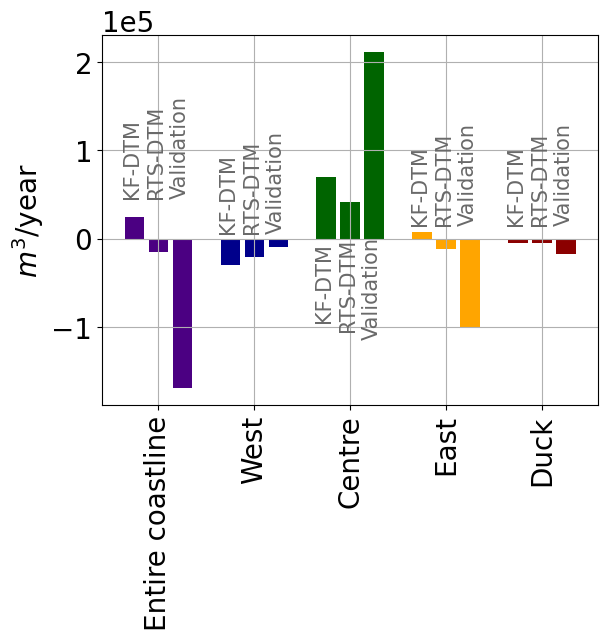

In [141]:
fig, ax = plt.subplots()
c_all = 'indigo'
ax.bar(0, trends['kf_all'], color=c_all)
ax.bar(1, trends['rts_all'], color=c_all)
ax.bar(2, trends['jarkus_all'], color=c_all)

fs = 15
textcolor = 'dimgrey'
ax.text(-.5, 50000, 'KF-DTM', rotation=90, fontsize=fs, c=textcolor)
ax.text(.5, 50000, 'RTS-DTM', rotation=90, fontsize=fs, c=textcolor)
ax.text(1.5, 50000, 'Validation', rotation=90, fontsize=fs, c=textcolor)

c_west = 'darkblue'
ax.bar(4, trends['kf_west'], color=c_west)
ax.bar(5, trends['rts_west'], color=c_west)
ax.bar(6, trends['jarkus_west'], color=c_west)

ax.text(3.5, 10000, 'KF-DTM', rotation=90, fontsize=fs, c=textcolor)
ax.text(4.5, 10000, 'RTS-DTM', rotation=90, fontsize=fs, c=textcolor)
ax.text(5.5, 10000, 'Validation', rotation=90, fontsize=fs, c=textcolor)

c_center = 'darkgreen'
ax.bar(8, trends['kf_center'], color=c_center)
ax.bar(9, trends['rts_center'], color=c_center)
ax.bar(10, trends['jarkus_center'], color=c_center)

ax.text(7.5, -90000, 'KF-DTM', rotation=90, fontsize=fs, c=textcolor)
ax.text(8.5, -100000, 'RTS-DTM', rotation=90, fontsize=fs, c=textcolor)
ax.text(9.5, -110000, 'Validation', rotation=90, fontsize=fs, c=textcolor)

c_east = 'orange'
ax.bar(12, trends['kf_east'], color=c_east)
ax.bar(13, trends['rts_east'], color=c_east)
ax.bar(14, trends['jarkus_east'], color=c_east)

ax.text(11.5, 20000, 'KF-DTM', rotation=90, fontsize=fs, c=textcolor)
ax.text(12.5, 20000, 'RTS-DTM', rotation=90, fontsize=fs, c=textcolor)
ax.text(13.5, 20000, 'Validation', rotation=90, fontsize=fs, c=textcolor)

c_duck = 'darkred'
ax.bar(16, trends_duck['kf'], color=c_duck)
ax.bar(17, trends_duck['rts'], color=c_duck)
ax.bar(18, trends_duck['vali'], color=c_duck)

ax.text(15.5, 20000, 'KF-DTM', rotation=90, fontsize=fs, c=textcolor)
ax.text(16.5, 20000, 'RTS-DTM', rotation=90, fontsize=fs, c=textcolor)
ax.text(17.5, 20000, 'Validation', rotation=90, fontsize=fs, c=textcolor)

ax.set_xticks([1,5,9,13, 17], ['Entire coastline', 'West', 'Centre', 'East', 'Duck'], rotation=90)

ax.set_ylabel(r'$m^3$/year')
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.grid()
plt.savefig(f'{path_output}validation_trend_barplot.png', dpi=300, bbox_inches='tight')

In [89]:
# trend difference rts-jarkus
print('all:', round(trends['rts_all'] - trends['jarkus_all'],1), 'm^3/year')
print('west:', round(trends['rts_west'] - trends['jarkus_west'],1), 'm^3/year')
print('center:', round(trends['rts_center'] - trends['jarkus_center'],1), 'm^3/year')
print('east:', round(trends['rts_east'] - trends['jarkus_east'],1), 'm^3/year')

all: 153767.9 m^3/year
west: -11300.9 m^3/year
center: -168981.8 m^3/year
east: 88695.4 m^3/year


In [88]:
# relative trend difference (rts-jarkus)/jarkus
def get_rel_trend_diff(area):
    diff = trends[f'rts_{area}'] - trends[f'jarkus_{area}']
    t_perc = (np.abs(diff) / np.abs(trends[f'jarkus_{area}'])) * 100
    return t_perc

print('all:', round(get_rel_trend_diff('all'),1), '%')
print('west:', round(get_rel_trend_diff('west'),1), '%')
print('center:', round(get_rel_trend_diff('center'),1), '%')
print('east:', round(get_rel_trend_diff('east'),1), '%')


all: 90.8 %
west: 119.6 %
center: 80.2 %
east: 88.6 %


### Map

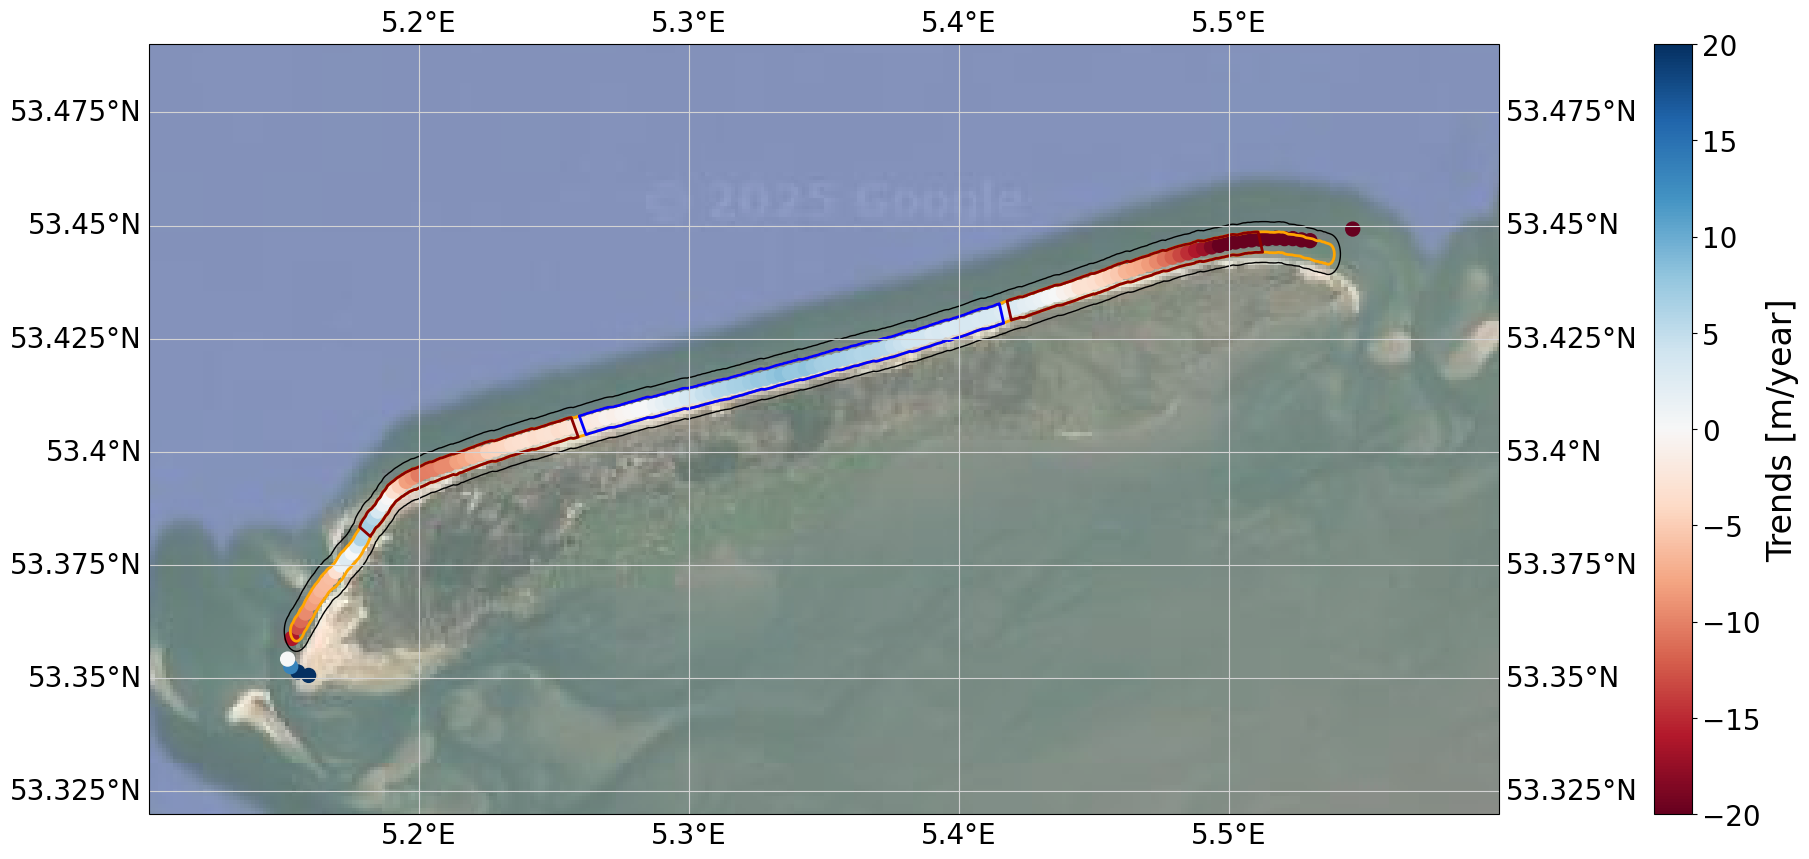

In [42]:
trend_jarkus = pd.read_pickle(path_input + '3_P1_output/' + 'trend_jarkus.pkl')
lon_mean = pickle.load(open(path_input + '3_P1_output/' + 'lon_mean.pkl', 'rb'))
lat_mean = pickle.load(open(path_input + '3_P1_output/' + 'lat_mean.pkl', 'rb'))

fig, ax = plt.subplots(figsize=(25,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

trends = ax.scatter(lon_mean, lat_mean, marker='o', s=100, c=trend_jarkus['var_psmsl_uncorr'],
                  cmap='RdBu', vmin=-20, vmax=20, transform=ccrs.PlateCarree())

ax.add_geometries(poly_target, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='black')
ax.add_geometries(poly_all, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='orange', linewidth=2)
ax.add_geometries(poly_west, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkred', linewidth=2)
ax.add_geometries(poly_center, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='blue', linewidth=2)
ax.add_geometries(poly_east, crs=ccrs.PlateCarree(), facecolor='none', edgecolor='darkred', linewidth=2)

plt.colorbar(trends, shrink=1, pad=.08).set_label(label='Trends [m/year]',size=24)
ax.set_title('')

plt.savefig(f'{path_output}volume_areas_jarkus_trends.png', dpi=300, bbox_inches='tight')

## Time series of elevation changes

### Statistics compared to JARKUS

In [43]:
elev_stats = pd.DataFrame(index=jarkus_gdf.index)

for jarkus_point in jarkus_gdf.index:
    rts_ts = rts_interp.drop(columns='geometry').iloc[jarkus_point]
    idx, = np.where(np.isin(jarkus_gdf.columns, rts_ts.index)) # where jarkus years and rts years overlap
    jarkus_ts = jarkus_gdf.loc[jarkus_point].iloc[idx].astype(float)
    
    not_nan = np.logical_or(np.isnan(rts_ts), jarkus_ts.isna())
    # if number of nan values more than 50 % of the total number of values
    if not_nan.sum() > len(rts_ts)/2: # at least 50 % overlapping non-nan values
        continue
        
    # RMSE
    elev_stats.loc[jarkus_point, 'rmse'] = CD_statistics.RMSE_timeseries(rts_ts, jarkus_ts)
    
    # # Correlation
    elev_stats.loc[jarkus_point, 'corr'], elev_stats.loc[jarkus_point, 'pvalue'] = stats.pearsonr(jarkus_ts[~not_nan], rts_ts[~not_nan])
    
    # Trend in m/year, Cxx: cov.matrix, v: diff between observations and model
    elev_trend_rts, _, _ = CD_statistics.compute_trend_with_error(rts_ts.index.values.astype(int), rts_ts.values)
    elev_trend_jarkus, _, _ = CD_statistics.compute_trend_with_error(jarkus_ts.index.values.astype(int), jarkus_ts.values)
    elev_stats.loc[jarkus_point, 'trend_diff'] = elev_trend_rts - elev_trend_jarkus


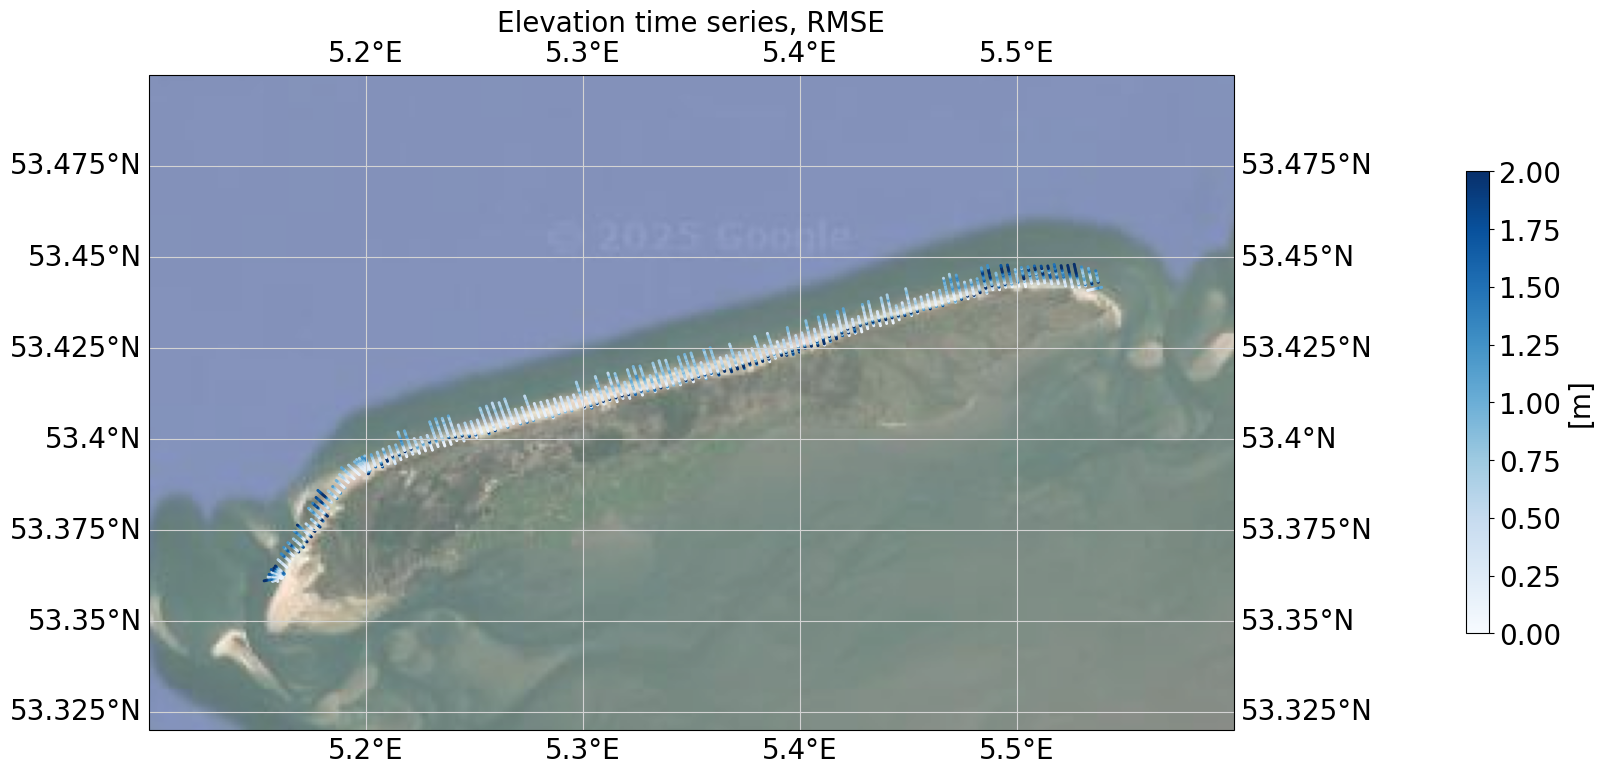

In [44]:
CD_visualisation.plot_map(4326, jarkus_gdf.geometry.x, jarkus_gdf.geometry.y, elev_stats['rmse'], vminmax=[0,2], cmap='Blues',
                          title='Elevation time series, RMSE', label='[m]')

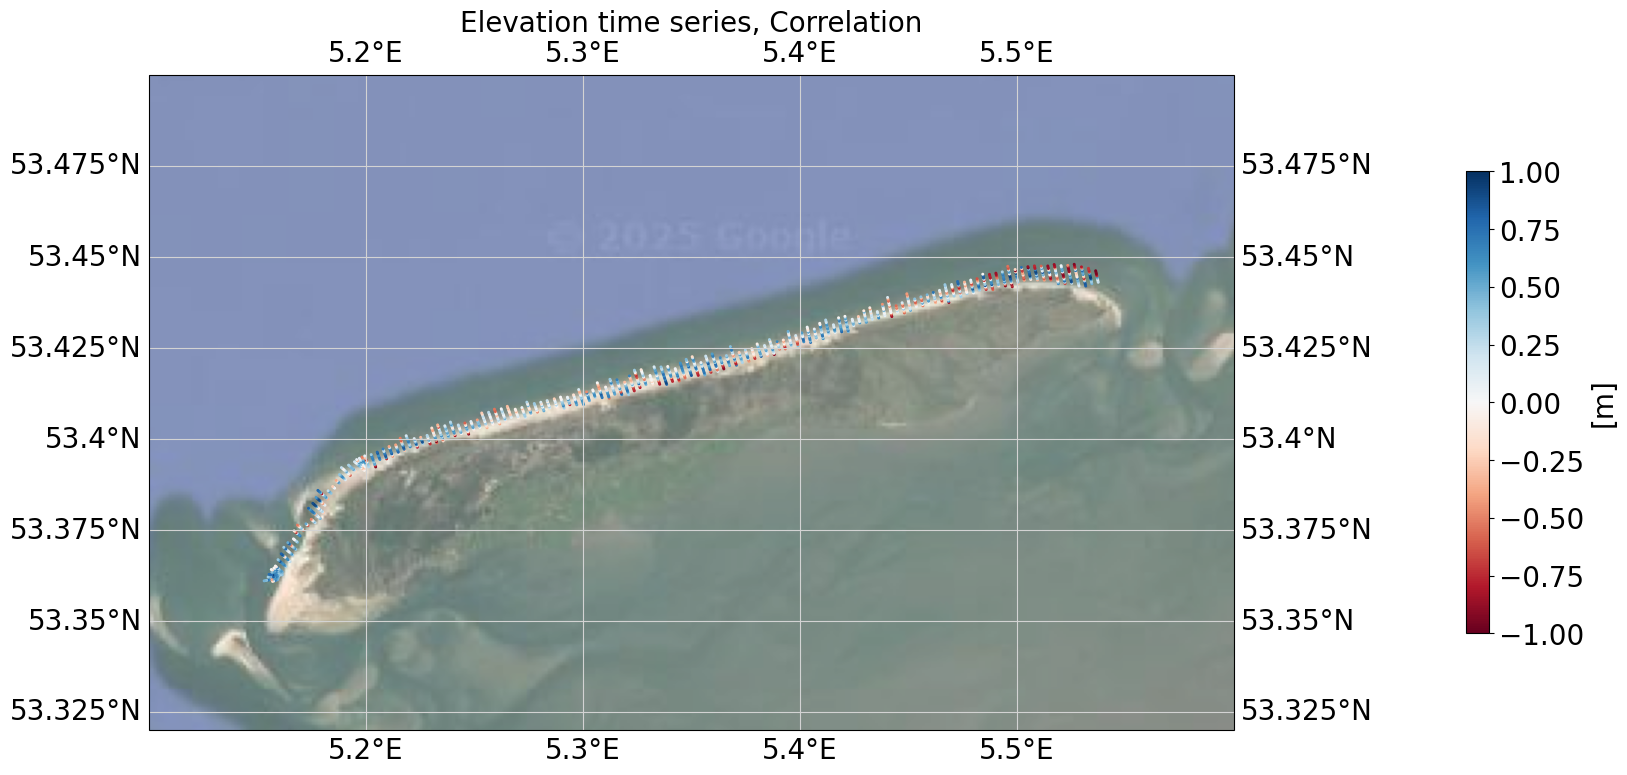

In [45]:
CD_visualisation.plot_map(4326, jarkus_gdf.geometry.x, jarkus_gdf.geometry.y, elev_stats['corr'], vminmax=[-1,1], cmap='RdBu',
                          title='Elevation time series, Correlation', label='[m]')

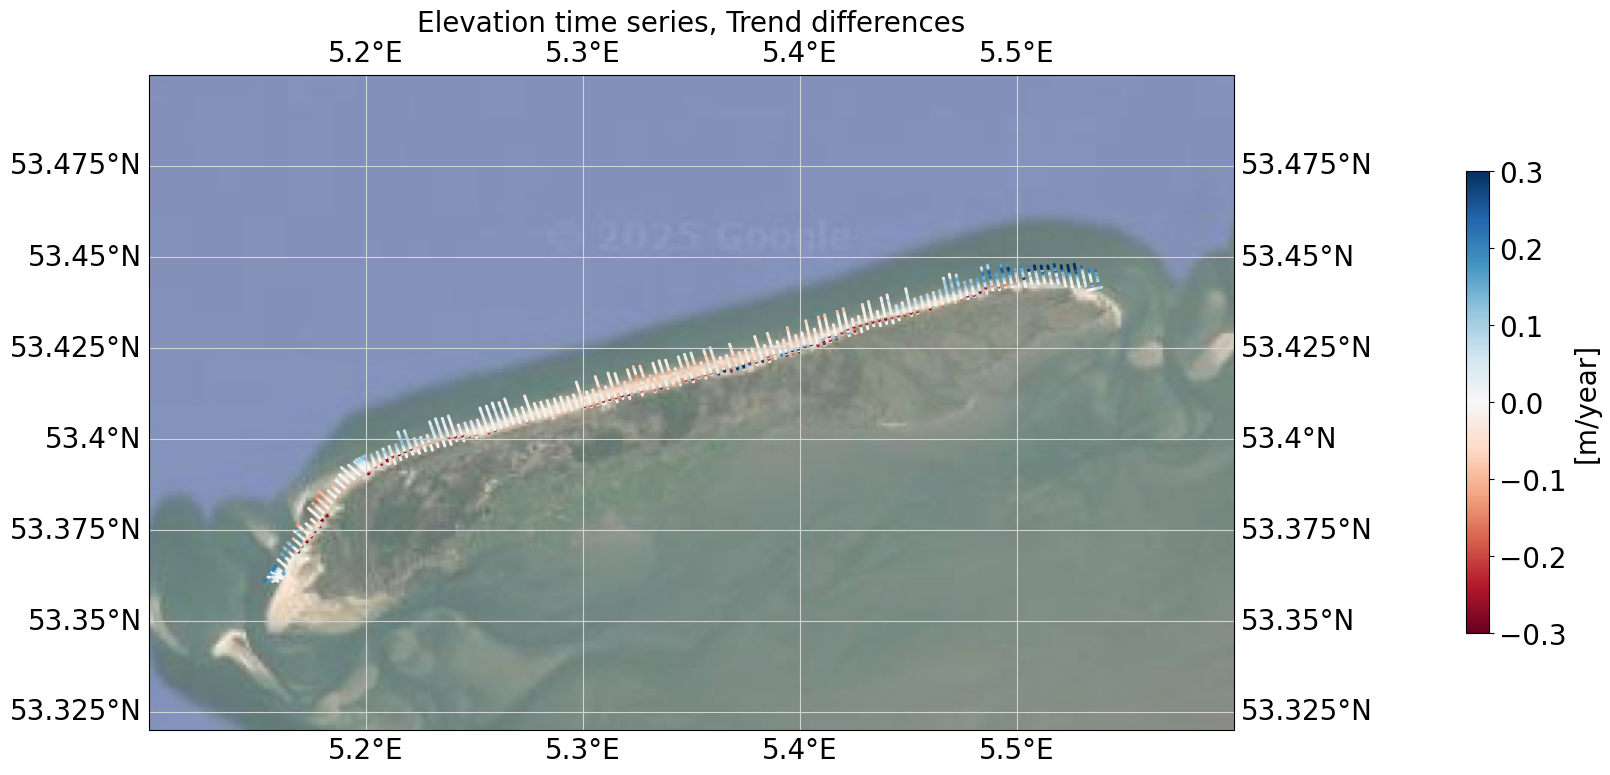

In [46]:
CD_visualisation.plot_map(4326, jarkus_gdf.geometry.x, jarkus_gdf.geometry.y, elev_stats['trend_diff'], vminmax=[-.3,.3], cmap='RdBu',
                          title='Elevation time series, Trend differences', label='[m/year]')

## Animation

In [47]:
poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=0)

#### KF

In [48]:
if animation:
    col_idx = ['x_' in _ for _ in x_state.columns]
    col_list_kf = x_state.loc[:,col_idx].columns.to_list()
    col_list_kf[1] = 'init'
    del col_list_kf[0]
    
    x_state_in_sl_poly = x_state[x_state.intersects(poly_sl_corr)]
    
    x = x_state_in_sl_poly.geometry.x
    y = x_state_in_sl_poly.geometry.y
    anim = CD_visualisation.movie(x_state_in_sl_poly, x, y,
            col_list_kf, first_col='init', extent=[5.1, 5.6, 53.32, 53.5], zoom=10,
            pixelsize=1, savepath=path_output, fn='KF.gif')

#### RTS

In [49]:
if animation:
    col_idx = ['x_s' in _ for _ in x_state_s.columns]
    col_list_s = x_state_s.loc[:,col_idx].columns.to_list()
    
    x_state_s_in_sl_poly = x_state_s[x_state_s.intersects(poly_sl_corr)]
    x = x_state_s_in_sl_poly.geometry.x
    y = x_state_s_in_sl_poly.geometry.y
    
    anim_RTS = CD_visualisation.movie(x_state_s_in_sl_poly, x, y,
                col_list_s, first_col='x_s_2020', extent=[5.1, 5.6, 53.32, 53.5], zoom=10,
                pixelsize=1, savepath=path_output, fn='RTS.gif')

#### Single year result map

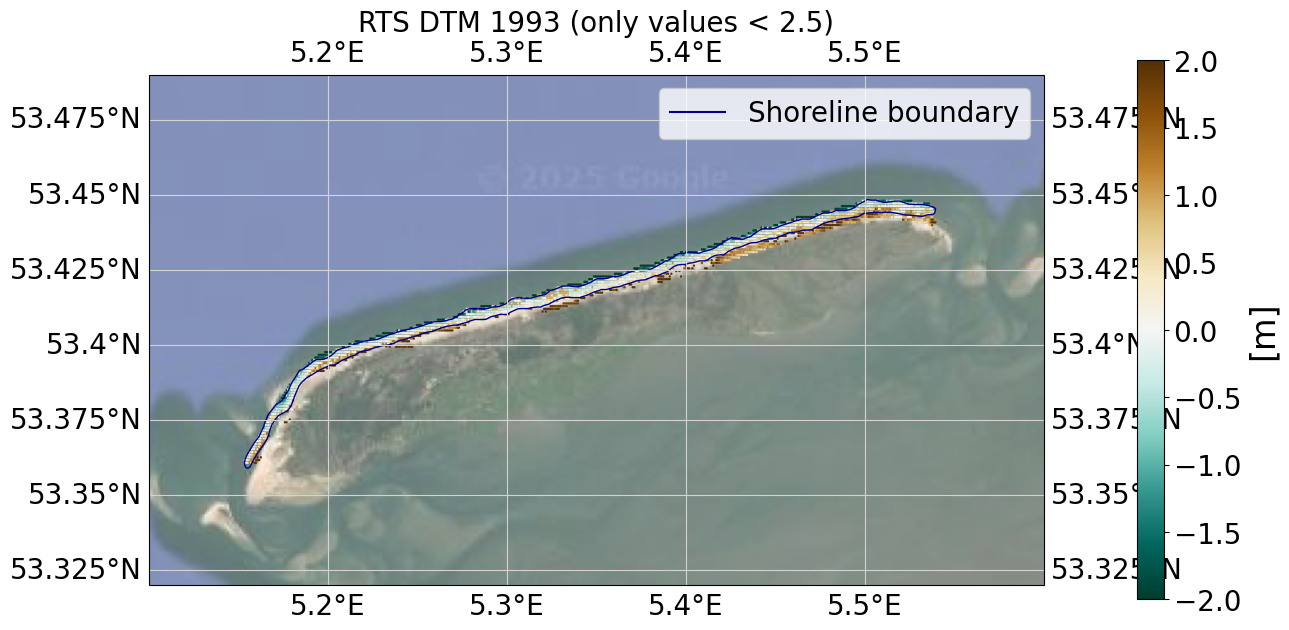

In [50]:
mask_max_elev = 2.5

# %matplotlib qt5
%matplotlib inline
projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=projection)
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

idx, = np.where(abs(x_state_s['x_s_1993']) < mask_max_elev)
x = x_state.geometry.x[idx]
y = x_state.geometry.y[idx]
data = x_state_s['x_s_1993'][idx]

# x = x_state.geometry.x
# y = x_state.geometry.y
# data = x_state_s['x_s_1993']

plot = ax.scatter(x, y, marker='o', s=.5, c = data,
                  cmap='BrBG_r', transform=ccrs.PlateCarree(), vmin=-2, vmax=2, )

ax.add_geometries(poly_sl_corr, crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

plt.colorbar(plot, shrink=.7, pad=.08).set_label(label='[m]',size=24)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])
ax.set_title(f'RTS DTM 1993 (only values < {mask_max_elev})')

plt.savefig(f'{path_output}RTS_DTM_1993.png', dpi=300, bbox_inches='tight')

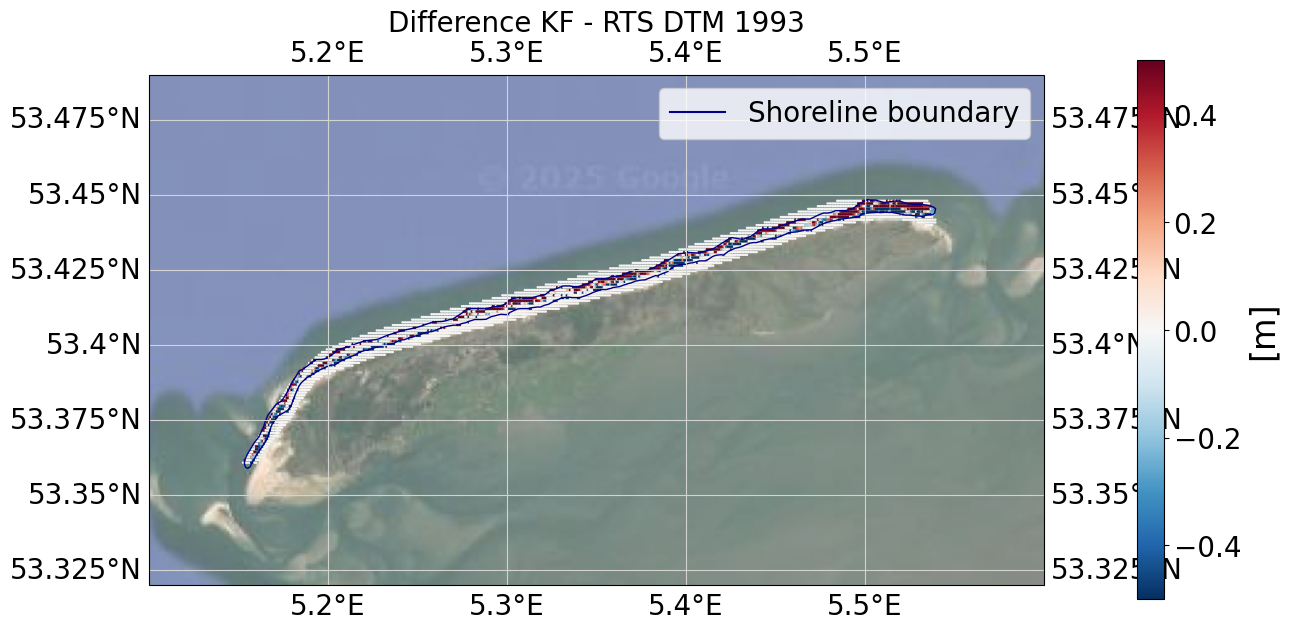

In [51]:
diff = x_state_s['x_s_1993'] - x_state['x_up_1993']

projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(15,10), subplot_kw=dict(projection=request.crs))
ax.set_extent([5.1, 5.6, 53.32, 53.49], crs=projection)
ax.gridlines(draw_labels=True, zorder=0, color='lightgrey')
request = cimgt.GoogleTiles(style="satellite")
zoom = 10
ax.add_image(request, zoom, alpha=0.7, zorder=0)

plot = ax.scatter(x_state.geometry.x, x_state.geometry.y, marker='o', s=.5, c=diff,
                  cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-.5, vmax=.5, )

ax.add_geometries(poly_sl_corr, crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

plt.colorbar(plot, shrink=.7, pad=.08).set_label(label='[m]',size=24)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])
ax.set_title('Difference KF - RTS DTM 1993');

plt.savefig(f'{path_output}diff_kf-rts_1993.png', dpi=300, bbox_inches='tight')